# CosMx RNA Cell Typing — PanCK-Gated Strategy

**Strategy**: Split cells by PanCK protein fluorescence into epithelial vs. non-epithelial, then type each subset separately with InSituType.

- **PanCK-low (non-epithelial)**: Semi-supervised InSituType with 15 reference types (Malignancy removed) + free clusters
- **PanCK-high (epithelial)**: Unsupervised InSituType to discover epithelial subtypes

```
QC-filtered Seurat object
         │
         ▼
   PanCK gate (threshold on Mean.PanCK)
        / \
       /   \
      ▼     ▼
 PanCK-low   PanCK-high
 (non-epi)   (epithelial)
      │           │
      ▼           ▼
 Supervised    Unsupervised
 InSituType    InSituType
      │           │
      ▼           ▼
    Merge annotations
         │
         ▼
   Posterior filter
         │
         ▼
   Final labeled object
```

## Setup & Libraries

In [1]:
# Load Packages
library("Seurat")
library("dplyr")
library(ggplot2)
library(gridExtra)
library(patchwork)
library(data.table)
library(Matrix)
library(ggrepel)
library(pals)
library(RColorBrewer)
library(ggrastr)
library(gtools)
library(InSituType)
library(HieraType)
library(tibble)

# Load helper functions and pipeline
source("helper_functions.R")
source("celltyping_pipeline.R")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




## Configuration

In [ ]:
# Define directories
file_path <- "../outputs/TMA18/seurat_objects/merged_object_TMA18.RDS"
reference_path <- "../inputs/InsituType_reference/BreastCancer_6k.profiles.csv"
out_dir <- "../outputs"
study_name <- "TMA18_CT_Explore"

out_dir_seu <- file.path(out_dir, study_name, "seurat_objects")
full_out_dir <- file.path(out_dir, study_name, "CT")
dir.create(full_out_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(out_dir_seu, showWarnings = FALSE, recursive = TRUE)

# Pipeline parameters
panck_threshold <- "auto"   # auto-detect from bimodal density valley (or set numeric e.g. 2500)
n_free_clusters <- 3        # free clusters for non-epithelial (semi-supervised)
n_clusters_epi <- 10        # clusters for epithelial (unsupervised)
min_posterior <- 0.5         # posterior probability cutoff
cohorting <- TRUE
n_cohorts <- 10

ASSAY_NAME <- "RNA"

## Load Data

In [4]:
# Load Seurat object
seu <- readRDS(file_path)
DefaultAssay(seu) <- ASSAY_NAME

message("Loaded Seurat object: ", ncol(seu), " cells, ", nrow(seu), " genes")
message("Metadata columns: ", paste(head(colnames(seu@meta.data), 30), collapse = ", "))

Loaded Seurat object: 206450 cells, 6175 genes

Metadata columns: fov, Area, AspectRatio, x_FOV_px, y_FOV_px, Width, Height, Mean.PanCK, Max.PanCK, Mean.G, Max.G, Mean.Membrane, Max.Membrane, Mean.CD45, Max.CD45, Mean.DAPI, Max.DAPI, SplitRatioToLocal, NucArea, NucAspectRatio, Circularity, Eccentricity, Perimeter, Solidity, cell_id, assay_type, version, Run_Tissue_name, Panel, cellSegmentationSetId



In [ ]:
# Load reference profiles
refprofiles <- read.csv(file.path(reference_path), row.names = 1, header = TRUE)

# Remove Malignancy — doesn't match our tumor cells
if ("Malignancy" %in% colnames(refprofiles)) {
  refprofiles <- refprofiles[, colnames(refprofiles) != "Malignancy"]
  message("Removed 'Malignancy' from reference profiles")
}

message("Reference profiles: ", nrow(refprofiles), " genes x ", ncol(refprofiles), " cell types")
message("Cell types: ", paste(colnames(refprofiles), collapse = ", "))

## Step 1: PanCK Threshold Exploration

PanCK threshold: 3500

  PanCK_high (epithelial):     82123 (39.8%)

  PanCK_low  (non-epithelial): 124327 (60.2%)



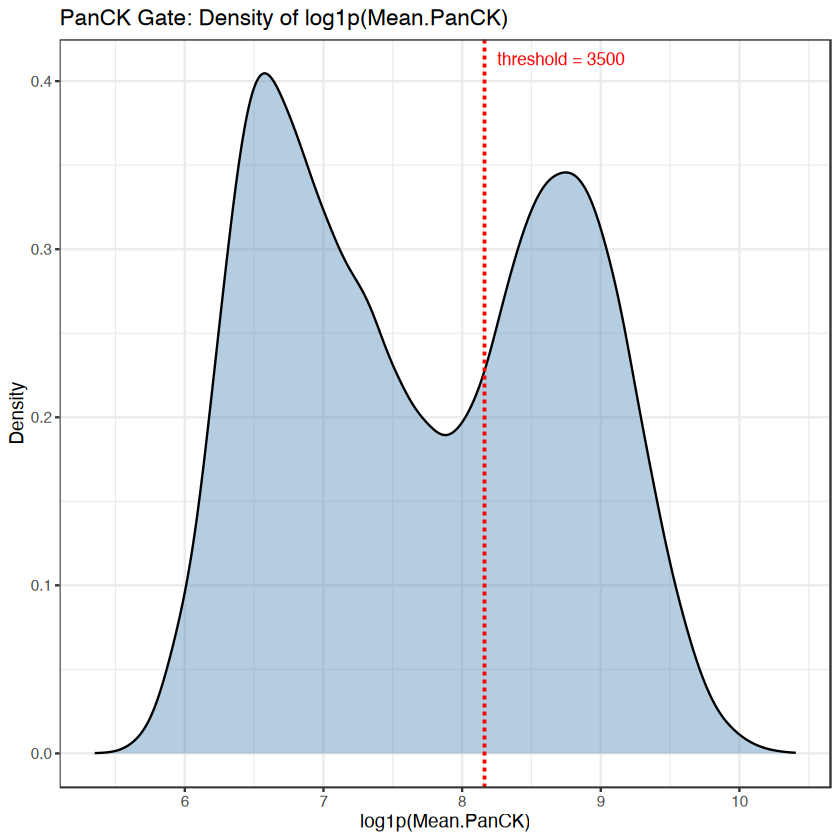

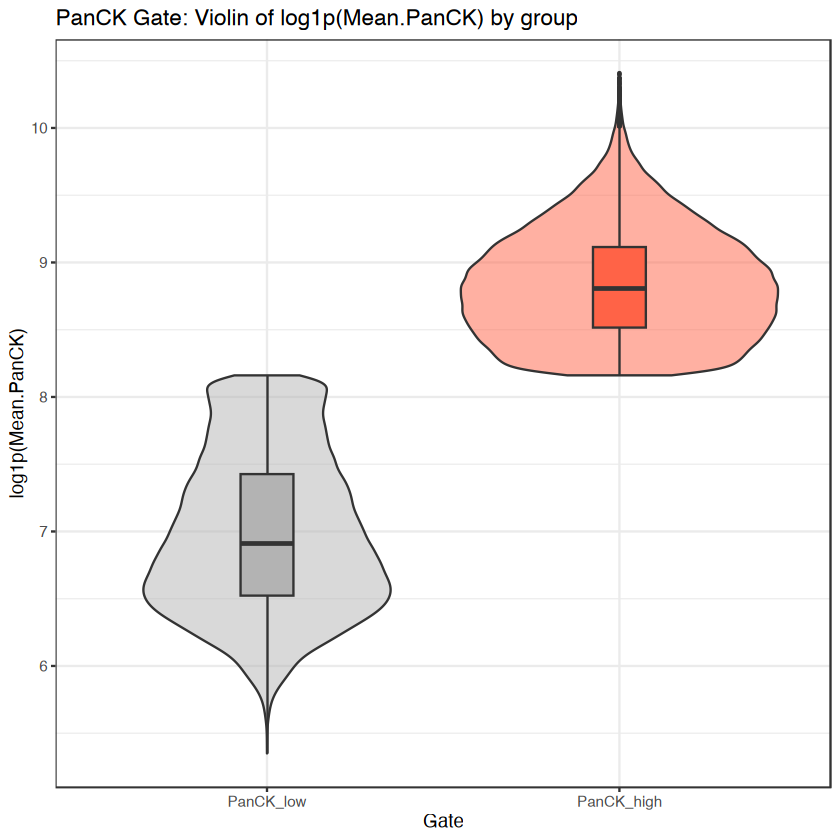

In [6]:
gate_result <- determine_panck_threshold(
  seu,
  panck_col = "Mean.PanCK",
  threshold = panck_threshold,
  output_dir = full_out_dir
)

PanCK threshold: 2500

  PanCK_high (epithelial):     95784 (46.4%)

  PanCK_low  (non-epithelial): 110666 (53.6%)



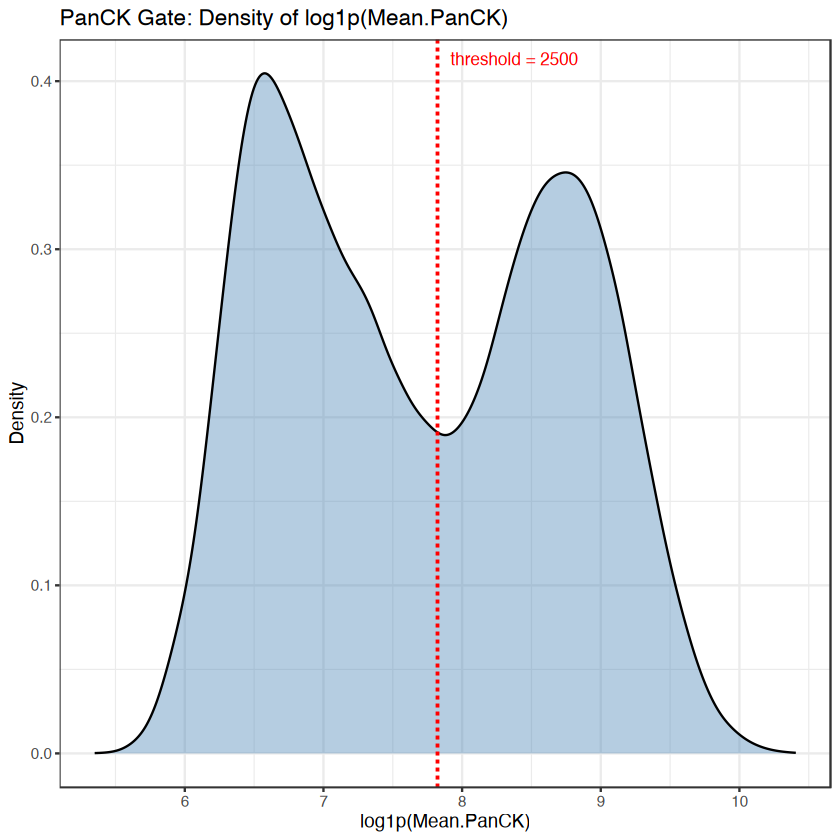

$threshold
[1] 2500

$gate
    [1] "PanCK_low"  "PanCK_low"  "PanCK_low"  "PanCK_low"  "PanCK_low" 
    [6] "PanCK_low"  "PanCK_high" "PanCK_low"  "PanCK_high" "PanCK_high"
   [11] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_low"  "PanCK_low" 
   [16] "PanCK_low"  "PanCK_low"  "PanCK_low"  "PanCK_low"  "PanCK_low" 
   [21] "PanCK_low"  "PanCK_low"  "PanCK_low"  "PanCK_low"  "PanCK_high"
   [26] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
   [31] "PanCK_low"  "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_low" 
   [36] "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
   [41] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
   [46] "PanCK_high" "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high"
   [51] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_low" 
   [56] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
   [61] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
   [66] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
   [71] "PanCK_low"  "PanCK_low"  "PanCK_low"  "PanCK_high" "PanCK_high"
   [76] "PanCK_high" "PanCK_high" "PanCK_low"  "PanCK_high" "PanCK_high"
   [81] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
   [86] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
   [91] "PanCK_high" "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high"
   [96] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [101] "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_low" 
  [106] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [111] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_low" 
  [116] "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [121] "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [126] "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [131] "PanCK_high" "PanCK_high" "PanCK_low"  "PanCK_high" "PanCK_low" 
  [136] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [141] "PanCK_high" "PanCK_low"  "PanCK_low"  "PanCK_high" "PanCK_low" 
  [146] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [151] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [156] "PanCK_high" "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high"
  [161] "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [166] "PanCK_high" "PanCK_high" "PanCK_low"  "PanCK_low"  "PanCK_high"
  [171] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_low"  "PanCK_high"
  [176] "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [181] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [186] "PanCK_high" "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high"
  [191] "PanCK_low"  "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_low" 
  [196] "PanCK_high" "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high"
  [201] "PanCK_high" "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high"
  [206] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [211] "PanCK_high" "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_low" 
  [216] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_low"  "PanCK_high"
  [221] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [226] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_low"  "PanCK_high"
  [231] "PanCK_high" "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high"
  [236] "PanCK_high" "PanCK_high" "PanCK_low"  "PanCK_low"  "PanCK_low" 
  [241] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_low"  "PanCK_high"
  [246] "PanCK_high" "PanCK_low"  "PanCK_high" "PanCK_high" "PanCK_high"
  [251] "PanCK_low"  "PanCK_low"  "PanCK_high" "PanCK_low"  "PanCK_high"
  [256] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [261] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [266] "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high" "PanCK_high"
  [271] "PanCK_high" "PanCK_hig

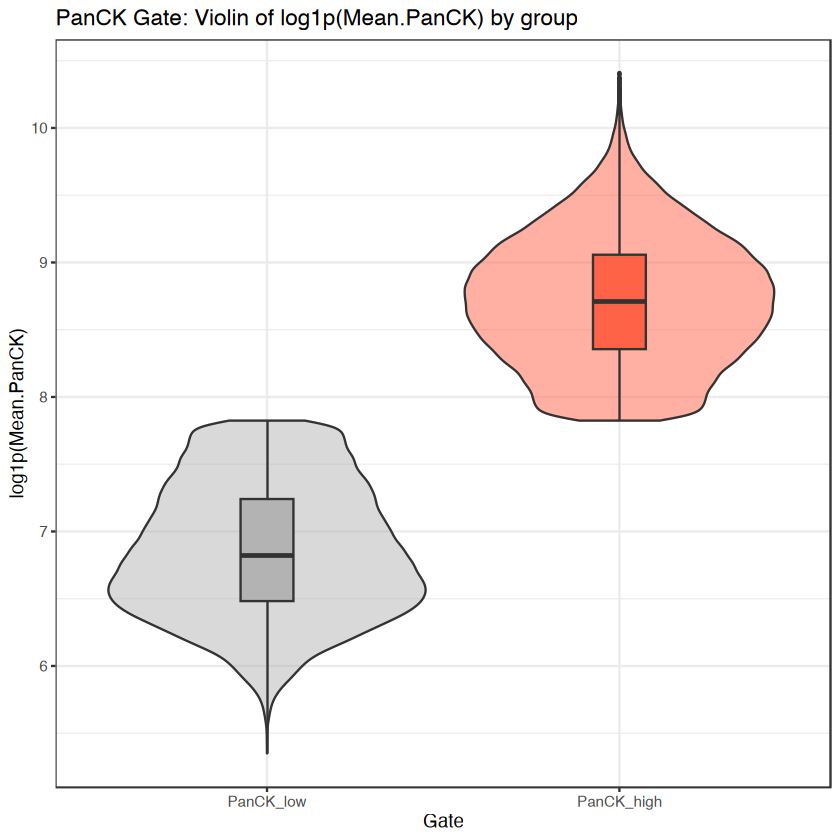

In [11]:
# Optional: try different thresholds to see the effect
determine_panck_threshold(seu, threshold = 2500, output_dir = full_out_dir)
# determine_panck_threshold(seu, threshold = 5000, output_dir = full_out_dir)

## Step 2: Split by PanCK Gate

In [13]:
split_result <- split_by_panck(
  seu,
  panck_col = "Mean.PanCK",
  threshold = panck_threshold
)

seu <- split_result$full
seu_nonepi <- split_result$nonepithelial
seu_epi <- split_result$epithelial

message("Non-epithelial: ", ncol(seu_nonepi), " cells")
message("Epithelial:     ", ncol(seu_epi), " cells")

Splitting by PanCK gate (threshold = 2500):

  PanCK_high (epithelial):     95784 cells

  PanCK_low  (non-epithelial): 110666 cells

Non-epithelial: 110666 cells

Epithelial:     95784 cells



## Step 3: Type Non-Epithelial Cells (PanCK-low)

Semi-supervised InSituType with 15 reference types (Malignancy removed) + free clusters.

In [ ]:
nonepi_result <- type_nonepithelial(
  seu_nonepi,
  reference_profiles = refprofiles,
  n_free_clusters = n_free_clusters,
  min_posterior = min_posterior,
  cohorting = cohorting,
  n_cohorts = n_cohorts,
  output_dir = full_out_dir
)

seu_nonepi <- nonepi_result$seurat_obj

In [ ]:
# Inspect non-epithelial results
table(seu_nonepi$celltype_nonepithelial)

In [ ]:
# Heatmap of non-epithelial cluster profiles
pheatmap::pheatmap(
  sweep(nonepi_result$ist_result$profiles, 1,
        pmax(apply(nonepi_result$ist_result$profiles, 1, max), 0.2), "/"),
  scale = "none",
  col = colorRampPalette(c("white", "darkblue"))(100),
  treeheight_row = 0, treeheight_col = 0,
  show_rownames = FALSE,
  main = "Non-epithelial cluster profiles"
)

## Step 4: Type Epithelial Cells (PanCK-high)

Unsupervised InSituType — no reference profiles. Discovers epithelial subtypes de novo.

In [ ]:
epi_result <- type_epithelial(
  seu_epi,
  n_clusters = n_clusters_epi,
  min_posterior = min_posterior,
  cohorting = cohorting,
  n_cohorts = n_cohorts,
  output_dir = full_out_dir
)

seu_epi <- epi_result$seurat_obj

In [ ]:
# Inspect epithelial results
table(seu_epi$celltype_epithelial)

In [ ]:
# Heatmap of epithelial cluster profiles
pheatmap::pheatmap(
  sweep(epi_result$ist_result$profiles, 1,
        pmax(apply(epi_result$ist_result$profiles, 1, max), 0.2), "/"),
  scale = "none",
  col = colorRampPalette(c("lightyellow", "darkred"))(100),
  treeheight_row = 0, treeheight_col = 0,
  show_rownames = FALSE,
  main = "Epithelial cluster profiles"
)

## Step 5: Merge Annotations

In [ ]:
seu <- merge_annotations(
  seu,
  seu_nonepi,
  seu_epi,
  output_dir = full_out_dir
)

In [ ]:
# Final cell type distribution
sort(table(seu$celltype_final), decreasing = TRUE)

## QC & Visualization

In [ ]:
# Spatial plot of final cell types
cluster_cls <- InSituType::colorCellTypes(
  freqs = table(seu$celltype_final),
  palette = "brewers"
)

xyplot(
  "celltype_final",
  x_column = "x_slide_mm",
  y_column = "y_slide_mm",
  cls = cluster_cls,
  metadata = seu@meta.data,
  ptsize = 0.01,
  show_legend = TRUE
) + ggtitle("Final Cell Types (PanCK-gated)")

In [ ]:
# Spatial plot of PanCK gate
gate_cls <- c("PanCK_high" = "tomato", "PanCK_low" = "grey70")

xyplot(
  "PanCK_gate",
  x_column = "x_slide_mm",
  y_column = "y_slide_mm",
  cls = gate_cls,
  metadata = seu@meta.data,
  ptsize = 0.01,
  show_legend = TRUE
) + ggtitle("PanCK Gate")

In [ ]:
# Characterize clusters with markers
res <- characterize_clusters(
  seurat_obj = seu,
  cluster_col = "celltype_final",
  cell_id_col = "cell_ID_new",
  n_top_markers = 15,
  output_dir = full_out_dir,
  prefix = "PanCK_gated"
)

In [ ]:
# View cluster summary
res$cluster_summary

In [ ]:
# View top markers for a specific cluster
head(res$top_markers[res$top_markers$cluster == "Epi_a", ], 10)

## Save Final Object

In [ ]:
# Save Seurat object
seu_filepath <- file.path(out_dir_seu, paste0("merged_object_", study_name, "_PanCK_gated.RDS"))
saveRDS(seu, seu_filepath)
message("Saved: ", seu_filepath)

# Save InSituType result objects
saveRDS(nonepi_result$ist_result, file.path(full_out_dir, "nonepithelial_IST_result.RDS"))
saveRDS(epi_result$ist_result, file.path(full_out_dir, "epithelial_IST_result.RDS"))
message("Saved InSituType result objects")